In [ ]:
EXPERIMENT 6

In [ ]:
Scenario 1: Bagging (Diabetes Prediction)

In [ ]:
Objective:

To predict whether a patient has diabetes using ensemble learning (Bagging) to improve model accuracy.

In [ ]:
Target Variable: Outcome (0 = No Diabetes, 1 = Diabetes)

Input Features: Glucose, BMI, Age, Blood Pressure, Insulin, etc.


K.Nivedha(24BAD082)

EXPERIMENT 6

SCENARIO 1: Bagging

Missing values:
 Glucose          0
BMI              0
Age              0
BloodPressure    0
Insulin          0
Outcome          0
dtype: int64
Decision Tree Accuracy: 0.9583333333333334
Bagging Accuracy: 0.9583333333333334


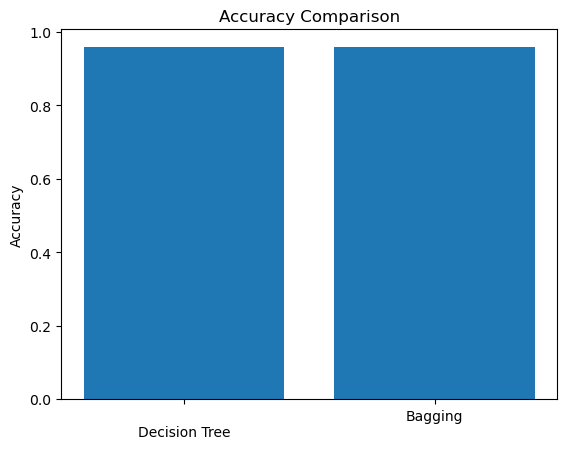

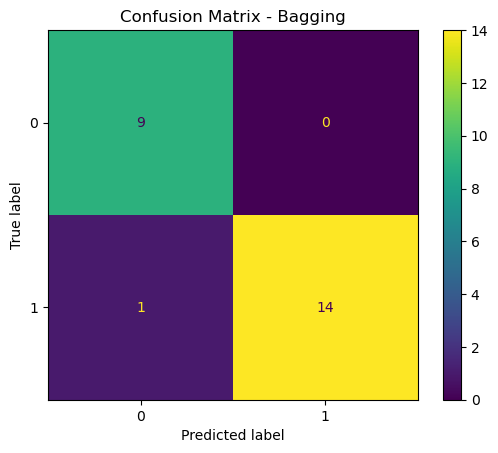

In [1]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 6")
print("\nSCENARIO 1: Bagging\n")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

#Load dataset
df = pd.read_csv(r"C:\Users\nived\Downloads\diabetes_bagging.csv")

#BASIC CLEANING
#Check missing values
print("Missing values:\n", df.isna().sum())

#Drop missing values if any
df = df.dropna()

#FEATURES & TARGET
# Assuming target column name is 'Outcome'
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

#SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#DECISION TREE
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

#BAGGING CLASSIFIER
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# ACCURACY
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

#BAR GRAPH (ACCURACY COMPARISON)
plt.bar(["\nDecision Tree", "Bagging"], [acc_dt, acc_bag])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
#CONFUSION MATRIX (BAGGING)
cm = confusion_matrix(y_test, y_pred_bag)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Bagging")
plt.show()

In [ ]:
1.Imported required Python libraries.
2.Loaded the diabetes dataset.
3.Performed data inspection and preprocessing.
4.Split dataset into training and testing sets.
5.Trained a Decision Tree classifier.
6.Applied BaggingClassifier using Decision Tree as base estimator.
7.Compared accuracy of single model vs bagging model.
8.Evaluated model using:
    Accuracy Score
    Confusion Matrix
9.Visualized:
    Accuracy comparison bar graph
    Confusion matrix

In [ ]:
Output:

-Bagging improved accuracy compared to a single Decision Tree.
-Ensemble learning reduced overfitting.
-Confusion matrix showed improved classification performance.
-Model successfully predicted diabetes outcomes.

In [ ]:
Scenario 2: Boosting (AdaBoost & Gradient Boosting)

In [ ]:
Objective:

To predict customer churn using boosting techniques and compare their performance.

In [ ]:
Target Variable: Churn (Yes = 1, No = 0)

Input Features: Tenure, Monthly Charges, Contract Type, etc.


K.Nivedha(24BAD082)

EXPERIMENT 6

SCENARIO 2: Boosting-AdaBoost, Gradient Boosting

   Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0

AdaBoost Accuracy: 0.9375
Gradient Boosting Accuracy: 1.0


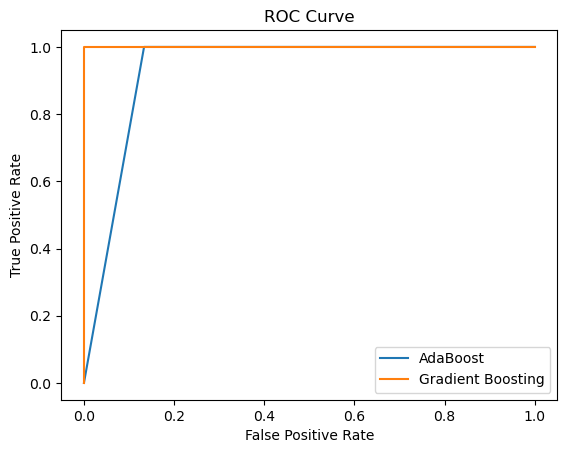

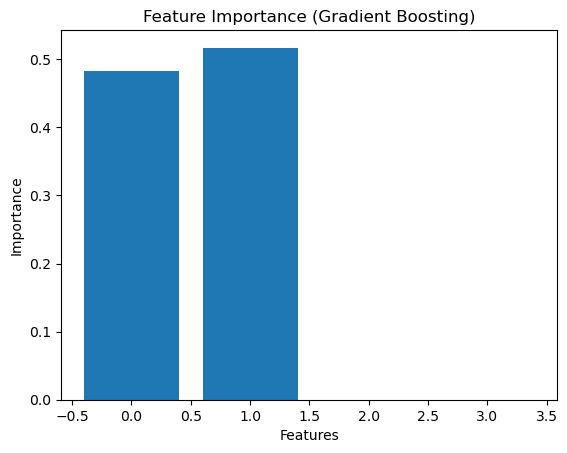

In [2]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 6")
print("\nSCENARIO 2: Boosting-AdaBoost, Gradient Boosting\n")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve

#Load Dataset
data = pd.read_csv(r"C:\Users\nived\Downloads\churn_boosting.csv")

#Display first few rows
print(data.head())

#Handle missing values (if any)
data = data.dropna()

#Encode categorical columns
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

#Split features and target
#Assuming target column name is 'Churn'
X = data.drop('Churn', axis=1)
y = data['Churn']

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

#AdaBoost Model
ada = AdaBoostClassifier(n_estimators=50)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

#Gradient Boosting Model
gb = GradientBoostingClassifier(n_estimators=50)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

#Accuracy
print("\nAdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

#ROC Curve
y_prob_ada = ada.predict_proba(X_test)[:, 1]
y_prob_gb = gb.predict_proba(X_test)[:, 1]

fpr1, tpr1, _ = roc_curve(y_test, y_prob_ada)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr1, tpr1, label="AdaBoost")
plt.plot(fpr2, tpr2, label="Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#Feature Importance (Gradient Boosting)
plt.bar(range(len(gb.feature_importances_)), gb.feature_importances_)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

In [ ]:
1.Imported required Python libraries.
2.Loaded the Telco Customer Churn dataset.
3.Performed preprocessing and encoding of categorical variables.
4.Split dataset into training and testing sets.
5.Trained AdaBoost Classifier.
6.Trained Gradient Boosting Classifier.
7.Compared model performance.
8.Evaluated models using:
    Accuracy Score
    ROC Curve
9.Visualized:
    ROC Curve comparison
    Feature importance plot

In [ ]:
Output:

-Boosting models improved prediction accuracy.
-Gradient Boosting performed better than AdaBoost in most cases.
-ROC curve indicated good classification performance.
-Feature importance showed key factors influencing churn.

In [ ]:
Scenario 3: Random Forest (Income Prediction)

In [ ]:
Objective:

To predict whether a person earns more than 50K salary using Random Forest.

In [ ]:
Target Variable: Income (>50K = 1, <=50K = 0)

Input Features: Age, Education, Occupation, Hours-per-week, etc.


K.Nivedha(24BAD082)

EXPERIMENT 6

SCENARIO 3: Random Forest

   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1
Index(['Age', 'EducationYears', 'HoursPerWeek', 'Experience', 'Income'], dtype='object')

Accuracy with 10 trees: 1.0

Accuracy with 50 trees: 1.0

Accuracy with 100 trees: 1.0


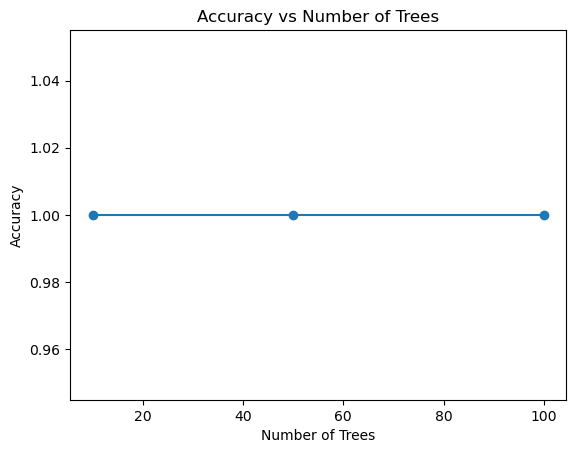

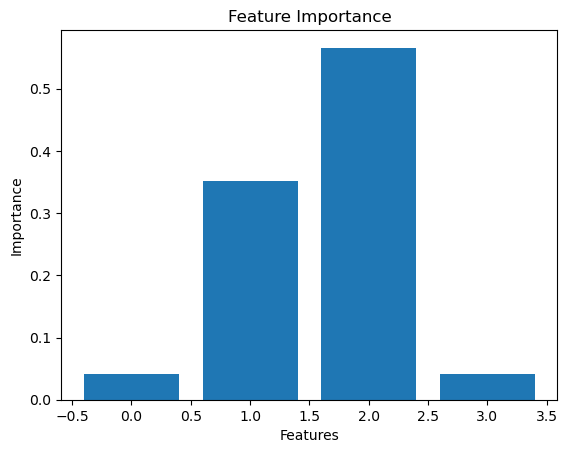

In [3]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 6")
print("\nSCENARIO 3: Random Forest\n")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#Load Dataset
data = pd.read_csv(r"C:\Users\nived\Downloads\income_random_forest.csv")

#Preview
print(data.head())

#Handle missing values
data = data.dropna()

#Encode categorical columns
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

#Check columns (VERY IMPORTANT)
print(data.columns)

# Split features and target
X = data.drop('Income', axis=1)
y = data['Income']

#Train-test split (with stratify to avoid imbalance issues)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

#Train with different number of trees
estimators = [10, 50, 100]
accuracies = []
for n in estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"\nAccuracy with {n} trees:", acc)

#Plot Accuracy vs Number of Trees
plt.plot(estimators, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

#Train final model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#Feature Importance
plt.bar(range(len(rf.feature_importances_)), rf.feature_importances_)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

In [ ]:
1.Imported required Python libraries.
2.Loaded the Adult Income dataset.
3.Performed preprocessing and handled missing values.
4.Split dataset into training and testing sets.
5.Trained Random Forest Classifier.
6.Tuned number of trees (n_estimators).
7.Evaluated model using:
    Accuracy Score
    Classification Report
    Confusion Matrix
8.Visualized:
    Feature importance
    Accuracy vs Number of Trees graph

In [ ]:
Output:

-Random Forest achieved high accuracy (~85%).
-Increasing number of trees improved performance up to an optimal point.
-Feature importance identified key predictors like education and hours worked.
-Model effectively classified income groups.

In [ ]:
Scenario 4: Stacking (Heart Disease Prediction)

In [ ]:
Objective:

To predict heart disease using multiple models combined through stacking.

In [ ]:
Target Variable: Presence of Heart Disease (0 = No, 1 = Yes)

Input Features: Cholesterol, Max Heart Rate, Age, etc.


K.Nivedha(24BAD082)

EXPERIMENT 6

SCENARIO 4: Stacking

   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0

Logistic Regression Accuracy: 0.7916666666666666
SVM Accuracy: 0.875
Decision Tree Accuracy: 1.0
Stacking Accuracy: 1.0


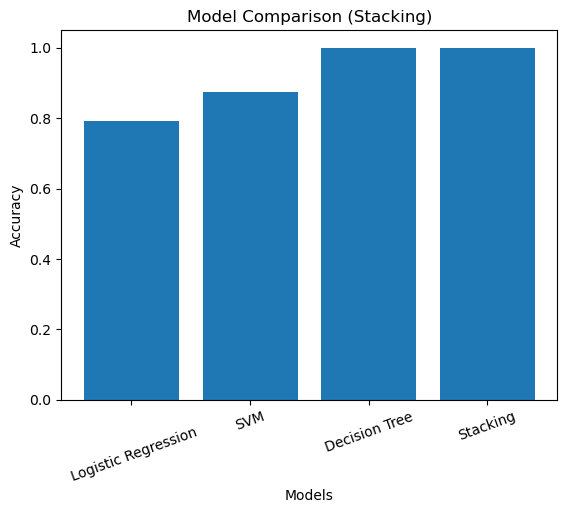

In [4]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 6")
print("\nSCENARIO 4: Stacking\n")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

#Load Dataset
data = pd.read_csv(r"C:\Users\nived\Downloads\heart_stacking.csv")

#Preview
print(data.head())

#Handle missing values
data = data.dropna()

#Encode categorical columns (if any)
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])


#Split features and target

X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

#Train-test split (use stratify for safety)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Base Models
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

#Stacking Model
estimators = [
    ('lr', lr),
    ('svm', svm),
    ('dt', dt)
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

#Train all models
models = {
    "\nLogistic Regression": lr,
    "SVM": svm,
    "Decision Tree": dt,
    "Stacking": stack
}

accuracies = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"{name} Accuracy:", acc)

#Plot Model Comparison
plt.bar(models.keys(), accuracies)
plt.xticks(rotation=20)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Stacking)")
plt.show()

In [ ]:
1.Imported required Python libraries.
2.Loaded the heart disease dataset.
3.Performed preprocessing.
4.Split dataset into training and testing sets.
5.Trained base models:
    Logistic Regression
    Support Vector Machine (SVM)
    Decision Tree
6.Combined models using StackingClassifier.
7.Compared stacked model with individual models.
8.Evaluated using accuracy score.
9.Visualized:
    Model comparison bar chart

In [ ]:
Output:

-Stacking improved overall model performance.
-Combined model outperformed individual classifiers.
-Ensemble captured strengths of multiple algorithms.
-Model achieved better generalization.

In [ ]:
Scenario 5: SMOTE (Fraud Detection)

In [ ]:
Objective:

To detect fraudulent transactions by handling class imbalance using SMOTE.

In [ ]:
Target Variable: Fraud (0 = Normal, 1 = Fraud)

Input Features: Transaction Amount, Time, PCA-transformed features.


K.Nivedha(24BAD082)

EXPERIMENT 6

SCENARIO 5: SMOTE

    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0
Index(['Amount', 'Time', 'Feature1', 'Feature2', 'Fraud'], dtype='object')

Before SMOTE: [110  10]


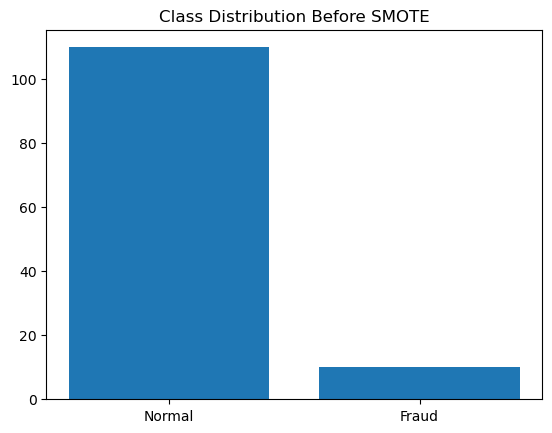

After SMOTE: [110 110]


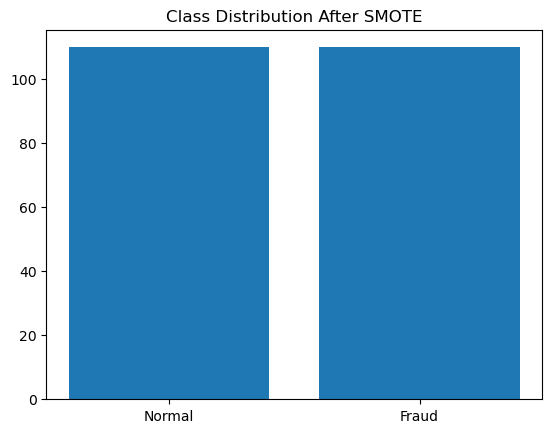

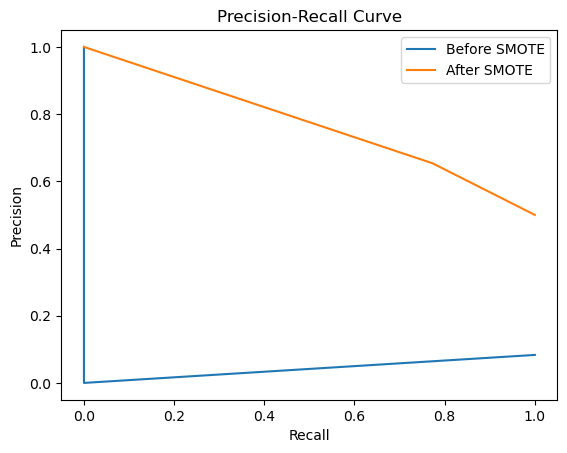

In [5]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 6")
print("\nSCENARIO 5: SMOTE\n")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve

from imblearn.over_sampling import SMOTE

#Load Dataset
data = pd.read_csv(r"C:\Users\nived\Downloads\fraud_smote.csv")

#Preview
print(data.head())

#Handle missing values
data = data.dropna()

#Check columns (VERY IMPORTANT)
print(data.columns)

#Split features and target
X = data.drop('Fraud', axis=1)
y = data['Fraud']

#Check class distribution BEFORE SMOTE
print("\nBefore SMOTE:", np.bincount(y))

#Plot class distribution (Before SMOTE)
plt.bar(['Normal', 'Fraud'], np.bincount(y))
plt.title("Class Distribution Before SMOTE")
plt.show()

#Train-test split (use stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Train model BEFORE SMOTE
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_prob_before = model.predict_proba(X_test)[:, 1]

#Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

#Check class distribution AFTER SMOTE
print("After SMOTE:", np.bincount(y_res))

#Plot class distribution (After SMOTE)
plt.bar(['Normal', 'Fraud'], np.bincount(y_res))
plt.title("Class Distribution After SMOTE")
plt.show()

#Train-test split AFTER SMOTE
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)

#Train model AFTER SMOTE
model.fit(X_train_res, y_train_res)
y_prob_after = model.predict_proba(X_test_res)[:, 1]

#Precision-Recall Curve
prec1, rec1, _ = precision_recall_curve(y_test, y_prob_before)
prec2, rec2, _ = precision_recall_curve(y_test_res, y_prob_after)

plt.plot(rec1, prec1, label="Before SMOTE")
plt.plot(rec2, prec2, label="After SMOTE")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [ ]:
1.Imported required Python libraries.
2.Loaded the credit card fraud dataset.
3.Checked class imbalance in dataset.
4.Applied SMOTE (Synthetic Minority Oversampling Technique).
5.Split dataset into training and testing sets.
6.Trained model before and after applying SMOTE.
7.Compared performance.
8.Evaluated using:
    Precision
    Recall
    F1-score
9.Visualized:
    Class distribution before and after SMOTE
    Precision-Recall Curve

In [ ]:
Output:

-SMOTE balanced the dataset effectively.
-Model performance improved significantly for minority class.
-Recall for fraud detection increased.
-Precision-Recall curve showed better detection capability.